In [3]:
import os
import torch
import numpy as np
from tqdm import tqdm
from models._config import *
import models._config as c
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")

# 데이터 로드
def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)

train_dir = '/data/kiwan/LPI_KIWAN/'
test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_train_class_dB'

data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snrs_batch = numpy_load(save_dir, 'snr_batch.npy')
idxs_batch = numpy_load(save_dir, 'idx_batch.npy')

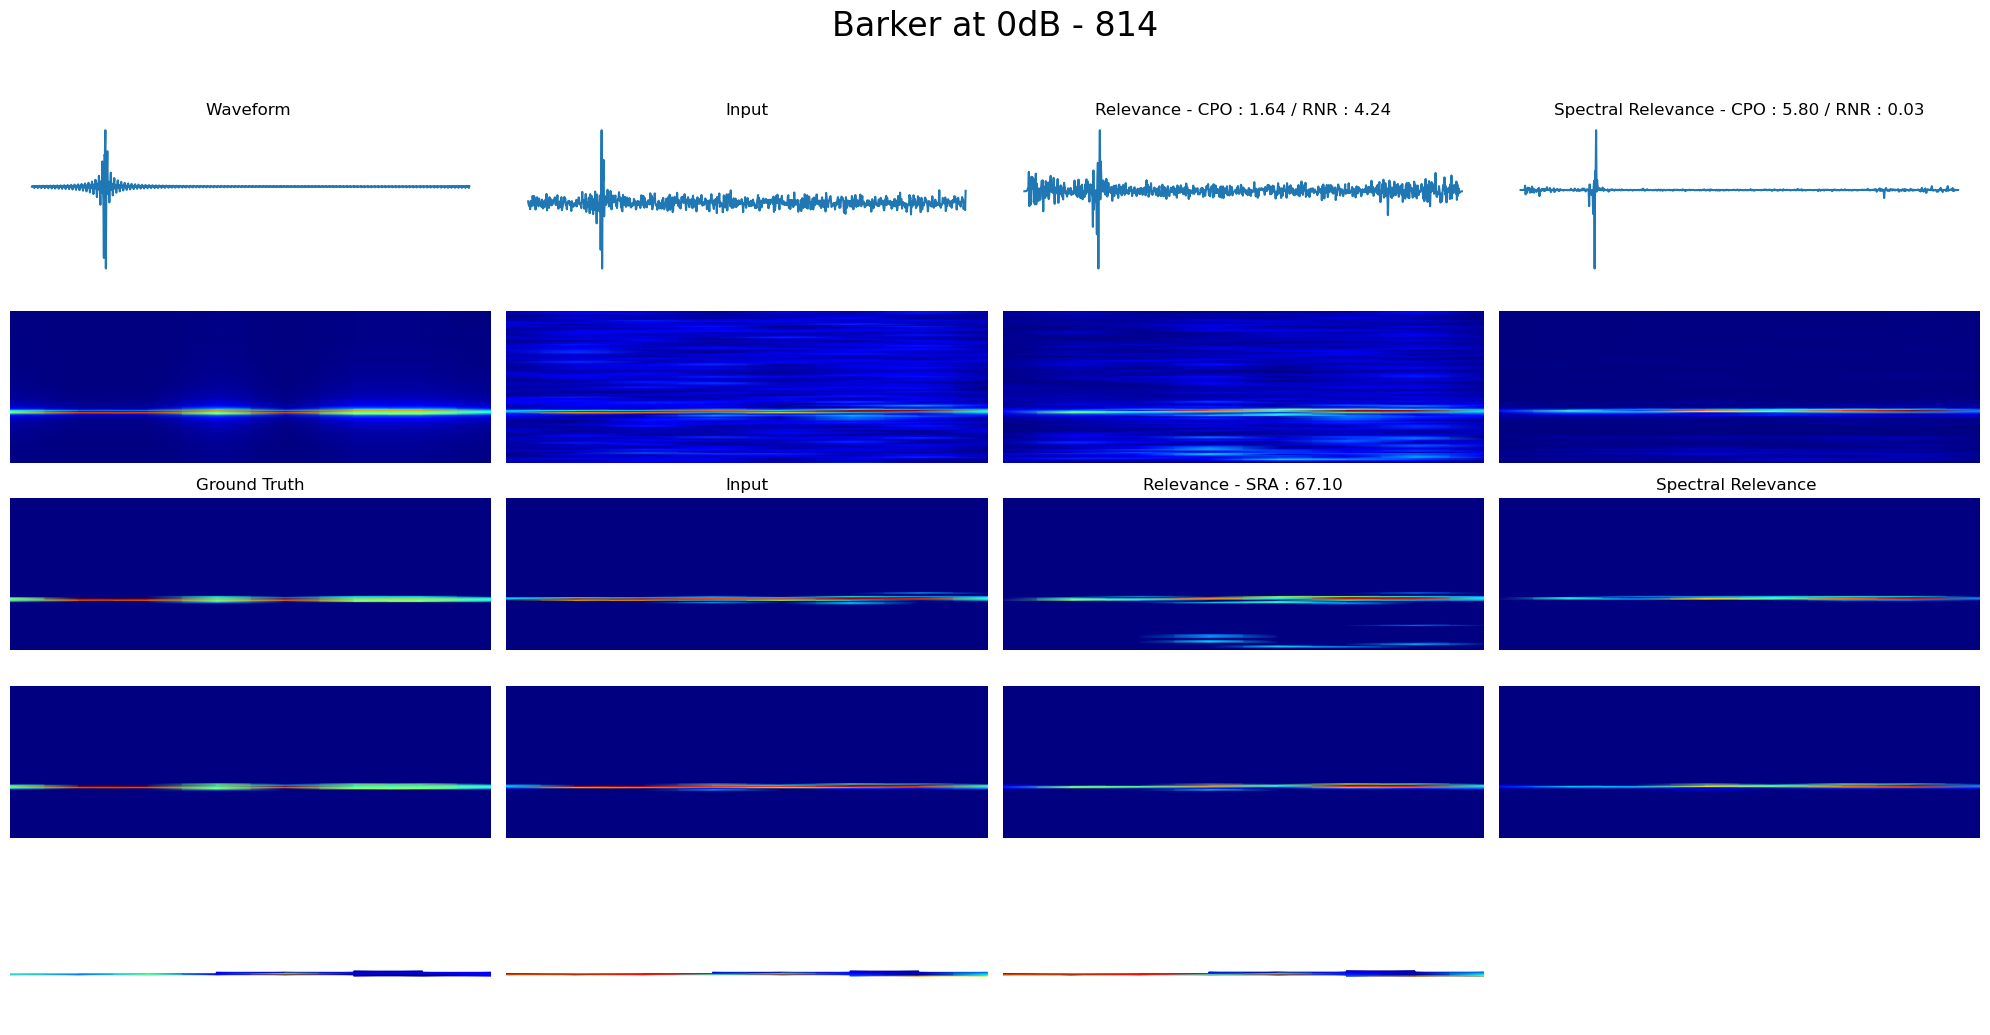

In [ ]:
shuffling = True
snr_values = sorted(set(snrs_batch.flatten())) 

class_complex = {cls: [] for cls in c.waveforms}

def critical_overlaps(wav, R_x, fs=100e6, alpha=0.8):
    f_w, t_w, Z_w = stft_transform(wav.real, wav.imag, fs=fs)
    f_R, t_R, Z_R = stft_transform(R_x.real, R_x.imag, fs=fs)

    # 특징점 임계값 계산
    tau = alpha * np.max(np.abs(Z_w))
    
    # 특징점 영역 (Critical Point Set)
    P_feature = np.abs(Z_w) > tau

    # Relevance 신호의 특징점 영역 합산
    relevance_in_feature = np.sum(np.abs(Z_R) * P_feature)
    
    # Relevance 전체 크기 합산
    total_relevance = np.sum(np.abs(Z_R))

    # CPO 계산
    cpo_score = relevance_in_feature / total_relevance if total_relevance > 0 else 0
    return cpo_score

def relevance_noise(x, R_x, fs):
    f_x, t_x, Z_x = stft_transform(x.real, x.imag, fs=fs)
    f_R, t_R, Z_R = stft_transform(R_x.real, R_x.imag, fs=fs)

    # 유클리디안 거리 계산
    diff = np.linalg.norm(Z_R - Z_x, ord=2)
    norm = np.linalg.norm(Z_x, ord=2)

    rnr_score = 1 - (diff / norm if norm > 0 else 0)
    return rnr_score


import metrics as m

def z_mask(Zxx, threshold=0.6):
    return np.where(np.abs(Zxx) > threshold * np.abs(Zxx).max(), 1, 0)

def z_norm(Z):
    Z_min, Z_max = np.min(Z), np.max(Z)
    return (Z - Z_min) / (Z_max - Z_min) if Z_max > Z_min else Z

for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    datab = data_dict[batch_key]
    labelb = labels_dict[batch_key]
    relevanceb = relevance_dict[batch_key]

    if shuffling:
        datab, labelb, lengthb, relevanceb, snrb, idxb = shuffle(datab, labelb, lengths_batch[batch], relevanceb, snrs_batch[batch], idxs_batch[batch])
    else: 
        datab, labelb, lengthb, relevanceb, snrb, idxb = datab, labelb, lengths_batch[batch], relevanceb, snrs_batch[batch], idxs_batch[batch]
    
    datasets = [(d, l, le, r, s, i) for d, l, le, r, s, i in zip(datab, labelb, lengthb, relevanceb, snrb, idxb) if s == 0]
    for j, sample in enumerate(datasets):
        
        data, label, length, relevance, snr, idx = sample
        
        fig, axes = plt.subplots(5, 4, figsize=(20, 10))
        fig.suptitle(f'{c.waveforms[label]} at {snr}dB - {idx}', fontsize=24, y=1.03)
        
        wav_path = os.path.join(train_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
        wav = np.load(wav_path)
        
        x = data[:length].cpu().numpy().T
        R_x = relevance[:length].cpu().numpy().T
        R_x = highpass_filter(R_x, 1e6, fs)
        
        x = comp(x[0], x[1])
        R_x = comp(R_x[0], R_x[1])
        f, a, fft = fft_transform(x.real, x.imag)
        R_f, R_a, R_fft = fft_transform(R_x.real, R_x.imag)
        
        y_k = np.abs(R_fft) / np.sum(np.abs(R_fft))
        y_k = y_k * R_fft
        
        y_k = ifft_transform(y_k)
        
        wf, wa, wfft = fft_transform(wav.real, wav.imag)
        xf, xa, xfft = fft_transform(x.real, x.imag)
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        kf, ka, kfft = fft_transform(y_k.real, y_k.imag)
        
        fw, tw, Zww = stft_transform(wav.real, wav.imag)
        fx, tx, Zxx = stft_transform(x.real, x.imag)
        fr, tr, Zrr = stft_transform(R_x.real, R_x.imag)
        fk, tk, Zkk = stft_transform(y_k.real, y_k.imag)
        
        Zww = z_norm(Zww)
        Zxx = z_norm(Zxx)
        Zrr = z_norm(Zrr)
        Zkk = z_norm(Zkk)
        
        metric1 = critical_overlaps(wav, R_x) *100
        metric1k = critical_overlaps(wav, y_k)*100
        metric2 = relevance_noise(x, R_x, 100e6)*100
        metric2k = relevance_noise(x, y_k, 100e6)*100
        
        axes[0, 0].set_title(f'Waveform ')
        axes[0, 1].set_title(f'Input')
        axes[0, 2].set_title(f'Relevance - CPO : {metric1:.2f} / RNR : {metric2:.2f}')
        axes[0, 3].set_title(f'Spectral Relevance - CPO : {metric1k:.2f} / RNR : {metric2k:.2f}')
        
        axes[0, 0].plot(wfft, label='Waveform')
        axes[0, 1].plot(xfft, label='Input')
        axes[0, 2].plot(rfft, label='Relevance')
        axes[0, 3].plot(kfft, label='spectral relevance')
        
        axes[1, 0].pcolormesh(tw, fw[:len(fw)//2], Zww[:len(fw)//2], shading='gouraud', cmap='jet')
        axes[1, 1].pcolormesh(tx, fx[:len(fx)//2], Zxx[:len(fx)//2], shading='gouraud', cmap='jet')
        axes[1, 2].pcolormesh(tr, fr[:len(fr)//2], Zrr[:len(fr)//2], shading='gouraud', cmap='jet')
        axes[1, 3].pcolormesh(tk, fk[:len(fk)//2], Zkk[:len(fk)//2], shading='gouraud', cmap='jet')
        
        def sra_metric(Z_gt, Z_input, Z_lrp, alpha=0.8, delta=0.8):
            # Create masks
            M_gt = (np.abs(Z_gt) > alpha * np.max(np.abs(Z_gt))).astype(float)  # Feature mask
            M_noise = 1 - M_gt  # Noise mask

            # Feature Concentration (FC)
            fc_num = np.sum(np.abs(M_gt) * np.abs(Z_lrp))
            fc_den = np.sum(np.abs(M_gt) * np.abs(Z_input))
            fc = fc_num / fc_den if fc_den > 0 else 0

            # Noise Reduction (NR)
            nr_num = np.sum(np.abs(M_noise) * np.abs(Z_lrp))
            nr_den = np.sum(np.abs(M_noise) * np.abs(Z_input))
            nr = 1 - (nr_num / nr_den if nr_den > 0 else 0)

            # SRA Score
            sra = delta * fc + (1 - delta) * nr
            return sra * 100      
        
        alpha = 0.25
        mask = z_mask(Zww, alpha)
        gt_mask = Zww * mask
        mask = z_mask(Zxx, alpha)
        x_mask = Zxx * mask
        mask = z_mask(Zrr, alpha)
        r_mask = Zrr * mask
        mask = z_mask(Zkk, alpha)
        k_mask = Zkk * mask
        
        score = sra_metric(Zww, Zxx, Zrr, 0.25)
        
        axes[2, 0].pcolormesh(tw, fw[:len(fw)//2], gt_mask[:len(fw)//2], shading='gouraud', cmap='jet')
        axes[2, 1].pcolormesh(tx, fx[:len(fx)//2], x_mask[:len(fx)//2], shading='gouraud', cmap='jet')
        axes[2, 2].pcolormesh(tr, fr[:len(fr)//2], r_mask[:len(fr)//2], shading='gouraud', cmap='jet')
        axes[2, 3].pcolormesh(tk, fk[:len(fk)//2], k_mask[:len(fk)//2], shading='gouraud', cmap='jet')
        axes[2, 0].set_title(f'Ground Truth')
        axes[2, 1].set_title(f'Input')
        axes[2, 2].set_title(f'Relevance - SRA : {score:.2f}')
        axes[2, 3].set_title(f'Spectral Relevance ')
        
        mask = z_mask(Zww, alpha)
        gt_mask = Zww * mask
        x_mask = Zxx * mask
        r_mask = Zrr * mask
        k_mask = Zkk * mask
        
        
        
        axes[3, 0].pcolormesh(tw, fw[:len(fw)//2], gt_mask[:len(fw)//2], shading='gouraud', cmap='jet')
        axes[3, 1].pcolormesh(tx, fx[:len(fx)//2], x_mask[:len(fx)//2], shading='gouraud', cmap='jet')
        axes[3, 2].pcolormesh(tr, fr[:len(fr)//2], r_mask[:len(fr)//2], shading='gouraud', cmap='jet')
        axes[3, 3].pcolormesh(tk, fk[:len(fk)//2], k_mask[:len(fk)//2], shading='gouraud', cmap='jet')
        
        
        r_sub = x_mask / r_mask
        k_sub = x_mask / k_mask
        axes[4, 0].pcolormesh(tw, fw[:len(fw)//2], r_sub[:len(fw)//2], shading='gouraud', cmap='jet')
        axes[4, 1].pcolormesh(tx, fx[:len(fx)//2], k_sub[:len(fx)//2], shading='gouraud', cmap='jet')
        # colorbar
        
        axes[4, 0].set_title(f'Relevance / Input')
        axes[4, 1].set_title(f'Spectral Relevance / Input')
        
        
        # for ax in axes[1, :]:
        #     plt.colorbar(ax.collections[0], ax=ax)
        # for ax in axes[2, :2]:
        #     plt.colorbar(ax.collections[0], ax=ax)
        
        
        for row_axes in axes:
            for ax in row_axes:
                ax.axis('off')
                ax.grid(alpha=0.3)
                if ax.get_legend():
                    ax.legend()
        break
    break

plt.tight_layout()

In [16]:

class LRP:
    def __init__(self, model, device, epsilon=1e-6):
        self.model = model
        self.epsilon = epsilon
        self.device = device
    
    def relevance(self, x, lengths, target=None, attributions=None, att=None):
        x = x.to(self.device)
        lengths = lengths.cpu()
        output, h, a = self.model(x, lengths, lstm_outputs=True)
        target = torch.argmax(output, dim=1) if target is None else target
        
        r = torch.zeros_like(output)
        for i in range(output.size(0)):
            r[i, target[i]] = output[i, target[i]]  # Target class에 대한 relevance만 생존

        # FC layer에 대한 relevance 계산 (LRP-all rule)
        r_c = self.bpp_fc(h, r)
        
        # Attention layer에 대한 relevance 계산 (Ω-LRP rule)
        r_h = self.bpp_att(r_c, h, a)
        
        # LSTM에 대한 relevance 계산 (lstm cell 내 각 게이트에 ε-LRP 및 Copy LRP 적용)
        r_x = self.bpp_bilstm(r_c, h, x, lengths) if att is None else self.bpp_bilstm(r_h, h, x, lengths)
        
        gt_label = torch.argmax(output, dim=1)
        
        if attributions is None:
            return r_x, gt_label
        else:
            return r_x, r_h, a, h, gt_label
    
    def lstm_gates(self, x_t, h_prev, W_ih, W_hh, b_ih, b_hh, cl_prev):
        x_t = x_t.to(self.device)
        h_prev = h_prev.to(self.device)
        cl_prev = cl_prev.to(self.device)
        
        gates = torch.matmul(W_ih, x_t) + torch.matmul(W_hh, h_prev) + b_ih + b_hh
        i_t, f_t, o_t, g_t = torch.chunk(gates, 4, dim=0)
        
        # Gate activations
        i_t = torch.sigmoid(i_t)  # Input gate
        f_t = torch.sigmoid(f_t)  # Forget gate
        o_t = torch.sigmoid(o_t)  # Output gate
        cl_t = f_t * cl_prev + i_t * torch.tanh(g_t)  # Cell state update
        
        return (f_t, i_t, o_t, cl_t)
        
    def bpp_bilstm(self, rel_h, h, x, lengths):
        B, T, H = h.size()
        H = H // 2
        D = x.size(-1)
        
        rel_x_fw = torch.zeros(B, T, D).to(self.device)
        rel_cl_fw_t1 = torch.zeros(B, H).to(self.device)
        W_ih = self.model.lstm.weight_ih_l0
        W_hh = self.model.lstm.weight_hh_l0
        b_ih = self.model.lstm.bias_ih_l0
        b_hh = self.model.lstm.bias_hh_l0
        
        rel_x_bw = torch.zeros(B, T, D).to(self.device)
        rel_cl_bw_t1 = torch.zeros(B, H).to(self.device)
        W_ih_bw = self.model.lstm.weight_ih_l0_reverse
        W_hh_bw = self.model.lstm.weight_hh_l0_reverse
        b_ih_bw = self.model.lstm.bias_ih_l0_reverse
        b_hh_bw = self.model.lstm.bias_hh_l0_reverse
        
        for i in range(B): 
            h_prev_fw = torch.zeros(H).to(self.device)
            cl_prev_fw = torch.zeros(H).to(self.device)
            for t in reversed(range(T)): 
                if t < lengths[i]:
                    x_t = x[i, t]
                    rel_h_fw_t = rel_h[i, t, :H]
                    
                    # LRP 규칙 적용
                    f_t, i_t, o_t, cl_t = self.lstm_gates(x_t, h_prev_fw, W_ih, W_hh, b_ih, b_hh, cl_prev_fw)
                    rel_x_fw[i, t], rel_cl_fw_t1[i] = self.bpp_lstm_cell(rel_h_fw_t, rel_cl_fw_t1[i], f_t, o_t, cl_t, W_ih)
                    cl_prev_fw = cl_t
            
            h_prev_bw = torch.zeros(H).to(self.device)
            cl_prev_bw = torch.zeros(H).to(self.device)
            for t in range(T):
                if t < lengths[i]:
                    x_t = x[i, t]
                    rel_h_bw_t = rel_h[i, t, H:]
                    bf_t, bi_t, bo_t, bcl_t = self.lstm_gates(x_t, h_prev_bw, W_ih_bw, W_hh_bw, b_ih_bw, b_hh_bw, cl_prev_bw)
                    rel_x_bw[i, t], rel_cl_bw_t1[i] = self.bpp_lstm_cell(rel_h_bw_t, rel_cl_bw_t1[i], bf_t, bo_t, bcl_t, W_ih_bw)
                    cl_prev_bw = bcl_t
                    
        rel_x = rel_x_fw + rel_x_bw
        return rel_x
        
    def bpp_lstm_cell(self, rel_h_t, rel_cl_t1, f_t, o_t, cl_t, W_ih):
        # ε-LRP rule 적용
        rel_cl_t = rel_cl_t1.to(self.device) + rel_h_t * o_t * (1 - torch.tanh(cl_t) ** 2 + self.epsilon)
    
        # Forget gate를 통해 relevance 전파 (Copy LRP rule 적용)
        rel_cl_t1 = rel_cl_t * f_t
        
        # Input gate의 relevance 전파 (Ω-LRP rule 적용)
        _, _, W_ih_o, W_ih_cl = torch.chunk(W_ih, 4, dim=0)
        
        rel_x_o = torch.matmul(W_ih_o.T, rel_cl_t * o_t)
        rel_x_cl = torch.matmul(W_ih_cl.T, rel_cl_t * torch.tanh(cl_t))
        
        # 최종 relevance 계산
        rel_x_t = rel_x_o + rel_x_cl
        return rel_x_t, rel_cl_t1
        
    def bpp_att(self, r_c, h, w):
        # Attention 단계에서 Ω-LRP rule 적용
        rel_h = torch.zeros_like(h).to(self.device)
        for i in range(h.size(0)):
            rel_h[i] = r_c[i].unsqueeze(0) * w[i].unsqueeze(-1)
        return rel_h
    
    def bpp_fc(self, c, r):
        # Fully Connected Layer에서 LRP-all rule 적용
        fc_W = self.model.fc.weight
        rel_c = torch.zeros_like(c).to(self.device)
        for i in range(r.size(0)):
            for j in range(r.size(1)):
                rel_c[i] += (c[i] * fc_W[j]) * r[i, j] / (fc_W[j].abs().sum() + self.epsilon)
        return rel_c

In [1]:
shuffling = False
snr_values = sorted(set(snrs_batch.flatten())) 



def load_models(path='./ckpts/result_loss.pt', device='cuda:0'):
    from models.LSTM import BiLSTM

    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    
    lrp = LRP(model, device=device, epsilon=1e-6)
    return model ,lrp

import seaborn as sns

model, lrp = load_models('ckpts/pwnNoisy/BiLSTM_best_0.0638087096589583.pth')
for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    datab = data_dict[batch_key]
    labelb = labels_dict[batch_key]
    relevanceb = relevance_dict[batch_key]
    
    if shuffling:
        datab, labelb, lengthb, relevanceb, snrb, idxb = shuffle(datab, labelb, lengths_batch[batch], relevanceb, snrs_batch[batch], idxs_batch[batch])
    else: 
        datab, labelb, lengthb, relevanceb, snrb, idxb = datab, labelb, lengths_batch[batch], relevanceb, snrs_batch[batch], idxs_batch[batch]
        
    for j, sample in enumerate(zip(datab, labelb, lengthb, relevanceb, snrb, idxb)):
        data, label, length, relevance, snr, idx = sample
        
        if snr != 0:
            continue
        
        fig, axes = plt.subplots(8, 4, figsize=(18, 20)) 
        fig.suptitle(f'{c.waveforms[label]} at {snr}dB - {idx}', fontsize=24, y=1.03)
        
        relevance_att, rel_h, att, hids, gt_label = lrp.relevance(data.unsqueeze(0), torch.tensor(length).unsqueeze(0), attributions=True, att=True)
        
        wav_path = os.path.join(train_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
        wav = np.load(wav_path)
        
        x = data[:length].cpu().numpy().T
        R_x = relevance[:length].cpu().numpy().T
        aR_x = relevance_att[:length].cpu().detach().numpy().squeeze().T    # (2, 1340)
        aR_h = rel_h[:length].cpu().detach().numpy().squeeze().T            # (256, 1340)
        aR_a = att[:length].cpu().detach().numpy().squeeze()                # (1340,)
        aR_hids = hids[:length].cpu().detach().numpy().squeeze().T          # (256, 1340)
        
        row = 2
        wf, wa, wfft = fft_transform(wav.real, wav.imag)
        f_w, t_w, Zxx_w = stft_transform(wav.real, wav.imag)
        axes[0, 0].plot(wav, label='Original Signal')
        axes[0, 1].plot(wfft, label='FFT of Original Signal')
        axes[0, 2].pcolormesh(t_w, f_w[:len(f_w)//2], Zxx_w[:len(f_w)//2], shading='gouraud', cmap='jet')
        # axes[0, 3]
        axes[0, 0].set_title('Original Signal (w)')
        
        # ---------------------------------------------------------
        R_ax = R_x * aR_x
        R_ax = highpass_filter(R_ax, 1e6, fs)
        
        aR_x = comp(aR_x[0], aR_x[1])
        R_ax = comp(R_ax[0], R_ax[1])
        axf, axa, axfft = fft_transform(R_ax.real, R_ax.imag)
        arf, ara, arfft = fft_transform(aR_x.real, aR_x.imag)
        f_ax, t_ax, Zxx_ax = stft_transform(R_ax.real, R_ax.imag)
        f_ar, t_ar, Zxx_ar = stft_transform(aR_x.real, aR_x.imag)
        axes[1, 0].plot(aR_x, label='Relevance with Att')
        axes[1, 1].plot(aR_a, label='Hidden States')
        axes[1, 2].plot(arfft, label='FFT of Relevance with Att')
        axes[1, 3].plot(axfft, label='FFT of Relevance')
        # axes[1, 3].pcolormesh(t_ax, f_ax[:len(f_ax)//2], Zxx_ax[:len(f_ax)//2], shading='gouraud', cmap='jet')
        
        # Row 1: 원본 데이터 및 FFT/STFT 결과
        R_x = highpass_filter(R_x, 1e6, fs)
        r = row
        x = comp(x[0], x[1])
        xf, xa, xfft = fft_transform(x.real, x.imag)
        f_x, t_x, Zxx_x = stft_transform(x.real, x.imag)
        axes[r, 0].plot(x, label='x')
        axes[r, 1].plot(xfft, label='FFT of x')
        axes[r, 2].pcolormesh(t_x, f_x[:len(f_x)//2], Zxx_x[:len(f_x)//2], shading='gouraud', cmap='jet')
        axes[r, 3].pcolormesh(t_ar, f_ar[:len(f_ar)//2], Zxx_ar[:len(f_ar)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Original Signal (x)')
        
        # Row 2: iFFT를 통해 복원된 데이터 결과
        r = row + 1
        i_x = relevance_k(xfft)
        ixf, ixa, ixfft = fft_transform(i_x.real, i_x.imag)
        f_ix, t_ix, Zxx_ix = stft_transform(i_x.real, i_x.imag)
        axes[r, 0].plot(i_x, label='iFFT of x')
        axes[r, 1].plot(ixfft, label='FFT of i_x')
        axes[r, 2].pcolormesh(t_ix, f_ix[:len(f_ix)//2], Zxx_ix[:len(f_ix)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Reconstructed Signal (i_x)')
        
        # Row 3: R>0인 원본 데이터 및 FFT/STFT 결과
        r = row + 2
        R_x = comp(R_x[0], R_x[1])
        xp = np.where(R_x > 0, x, 0)
        xpf, xpa, xpfft = fft_transform(xp.real, xp.imag)
        f_xp, t_xp, Zxx_xp = stft_transform(xp.real, xp.imag)
        axes[r, 0].plot(xp, label='x(R_x > 0)')
        axes[r, 1].plot(xfft, label='FFT of x(R_x > 0)')
        axes[r, 2].pcolormesh(t_xp, f_xp[:len(f_xp)//2], Zxx_xp[:len(f_xp)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Signal x(R_x > 0)')
        
        # Row 4 : R>0인 iFFT를 통해 복원된 데이터 결과
        r = row + 3
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        f_R_x, t_R_x, Zxx_R_x = stft_transform(R_x.real, R_x.imag)
        axes[r, 0].plot(R_x, label='R_x')
        axes[r, 1].plot(rfft, label='FFT of R_x')
        axes[r, 2].pcolormesh(t_R_x, f_R_x[:len(f_R_x)//2],  Zxx_R_x[:len(f_R_x)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Relevance (R_x)')
        
        # Row 5 : Relevance 및 FFT/STFT 결과
        r = row + 4
        R_x = np.where(R_x > 0, R_x, 0)
        R_x = highpass_filter(R_x, 1e6, fs)
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        f_R_x, t_R_x, Zxx_R_x = stft_transform(R_x.real, R_x.imag)
        axes[r, 0].plot(R_x, label='R_x')
        axes[r, 1].plot(rfft, label='FFT of R_x')
        axes[r, 2].pcolormesh(t_R_x, f_R_x[:len(f_R_x)//2],  Zxx_R_x[:len(f_R_x)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Relevance (R_x > 0)')
        
        # Row 6 : iFFT를 통해 복원된 Relevance 결과
        r = row + 5
        iR_k = relevance_k(rfft)
        rf, ra, rfft = fft_transform(iR_k.real, iR_k.imag)
        f_R_k, t_R_k, Zxx_R_k = stft_transform(iR_k.real, iR_k.imag)
        axes[r, 0].plot(iR_k, label='R_k')
        axes[r, 1].plot(rfft, label='FFT of R_k')
        axes[r, 2].pcolormesh(t_R_k, f_R_k[:len(f_R_k)//2],  Zxx_R_k[:len(f_R_k)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Reconstructed Relevance (R_k)')
        
        # Row 7

        
        # 공통 설정: 각 축에 라벨 추가
        for row_axes in axes:
            for ax in row_axes:
                ax.axis('off')
                ax.grid(alpha=0.3)
        break
    break
        
plt.tight_layout()
plt.show()
        
# cuda memory 초기화
torch.cuda.empty_cache()

NameError: name 'snrs_batch' is not defined

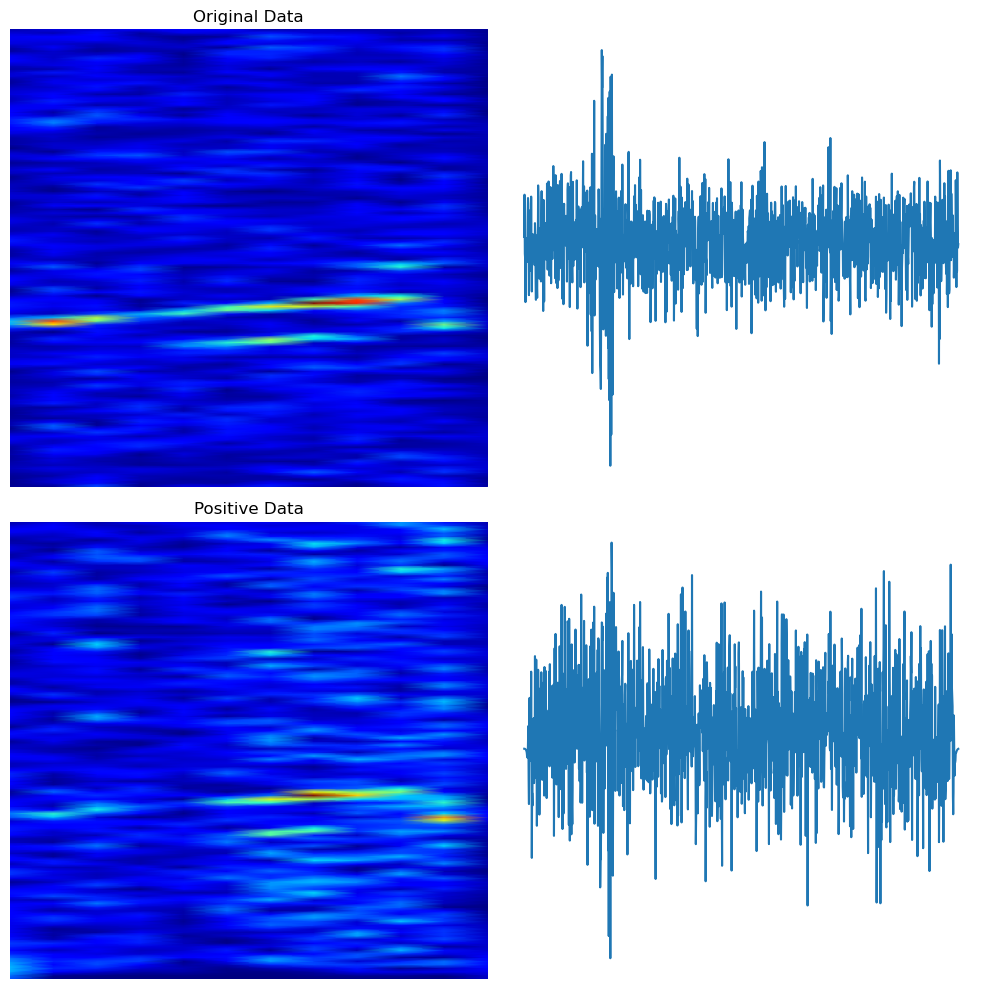

In [13]:

fs = 100e6
epochs = 500

losses = []
best_loss = float('inf')
best_state = None


import matplotlib.pyplot as plt
from sklearn.utils import shuffle

for batch in range(len(data_dict)):
    key = f'arr_{batch}'
    data_batch, label_batch, relevance_batch = data_dict[key], labels_dict[key], relevance_dict[key]
    length_batch, snr_batch, idx_batch = lengths_batch[batch], snrs_batch[batch], idxs_batch[batch]
    
    pos_data_batch = np.transpose(
            np.array([[d.real, d.imag] for d in [
                highpass_filter(comp(np.where(r[:, 0] > 0, d[:, 0], 0), 
                                    np.where(r[:, 1] > 0, d[:, 1], 0)), 1e6, fs) 
                for d, r in zip(data_batch, relevance_batch)
            ]]), (0, 2, 1)
        )      
    # fft_batch = [fft_transform(data, fs) for data in data_batch]
    # ifft_batch = [relevance_k(fft) for fft in fft_batch]
    
    batch_sample = shuffle(list(zip(data_batch, pos_data_batch, length_batch))) if shuffle else zip(data_batch, pos_data_batch, length_batch)

    for data, pos, l  in batch_sample:
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))
        data = data[:l]
        pos =   pos[:l]
        f, a, fft = fft_transform(data[:, 0], data[:, 1], fs)
        f, t, Zxx = stft_transform(data[:, 0], data[:, 1], fs)
        
        axes[0, 0].pcolormesh(t, f[:len(f)//2], Zxx[:len(f)//2], shading='gouraud', cmap='jet')
        axes[0, 0].set_title('Original Data')
        axes[0, 1].plot(fft)
        
        ff, aa, ffft = fft_transform(pos[:, 0], pos[:, 1], fs)
        ff, tt, tZxx = stft_transform(pos[:, 0], pos[:, 1], fs)
        axes[1, 0].pcolormesh(tt, ff[:len(ff)//2], tZxx[:len(ff)//2], shading='gouraud', cmap='jet')
        axes[1, 0].set_title('Positive Data')
        axes[1, 1].plot(ffft)
        
        
        for ax in axes.flatten():
            ax.axis('off')
            
        break
    break
        
plt.tight_layout()

/home/kiwan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kiwan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/kiwan/anaconda3/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:1870: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '


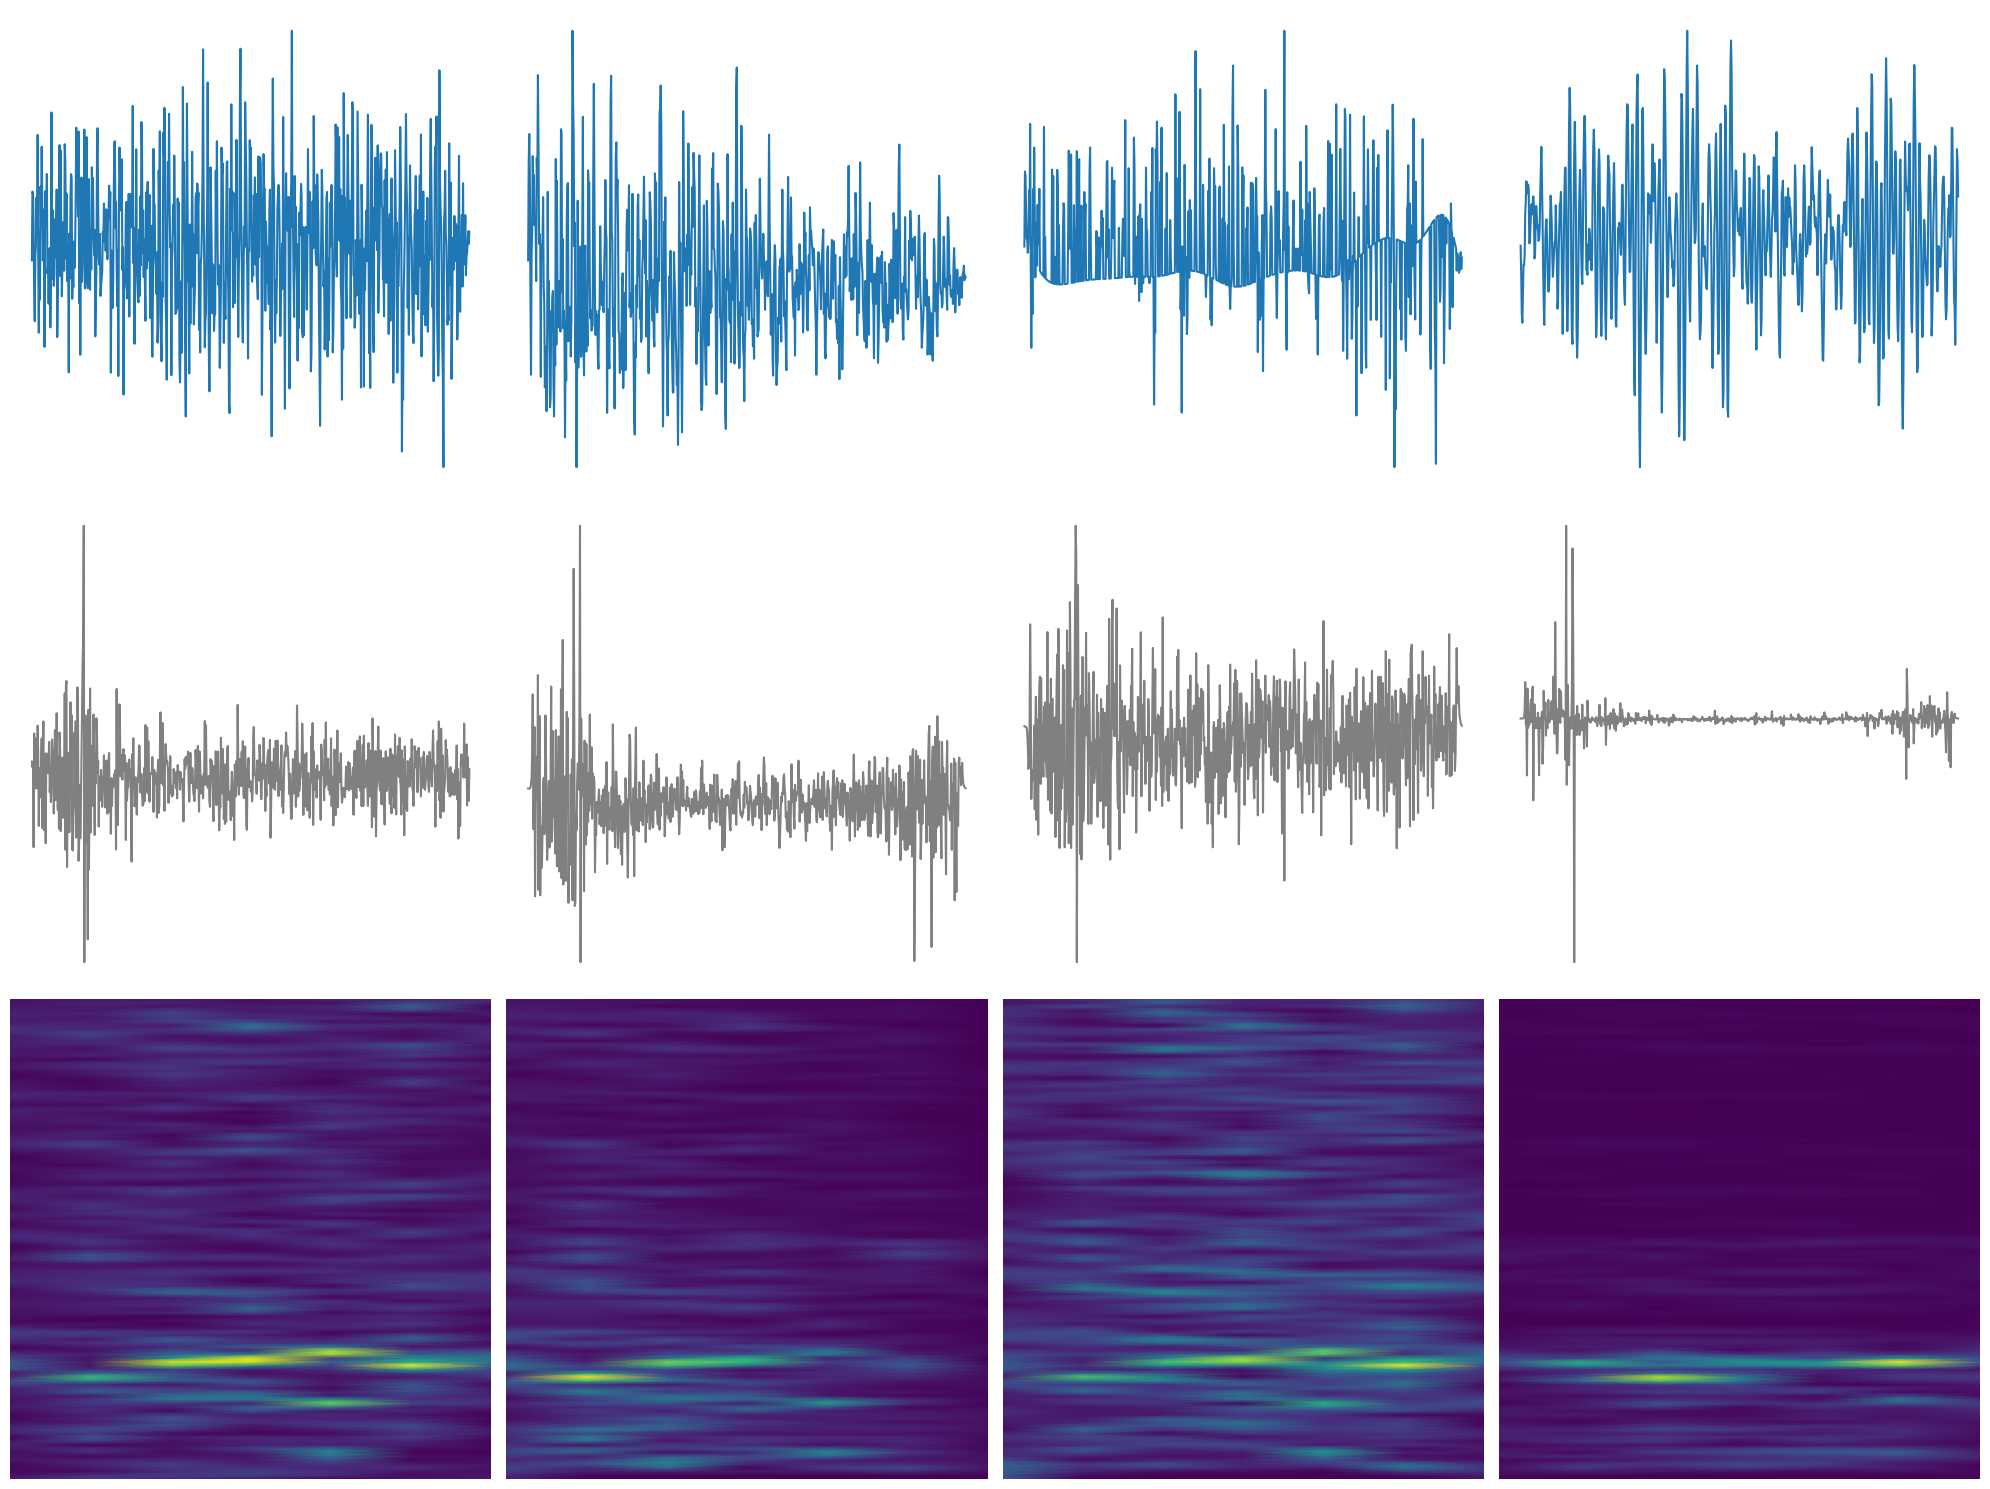

In [ ]:
import os
import torch
import numpy as np
from models._config import *

# 데이터 로드
def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)

test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_class_dB'


data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snr_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')

fs = 100e6
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

for batch in range(len(data_dict)):
    key = f'arr_{batch}'
    data_batch, label_batch, relevance_batch = data_dict[key], labels_dict[key], relevance_dict[key]
    length_batch, snr_batch, idx_batch = lengths_batch[batch], snr_batch[batch], idx_batch[batch]
    sample = zip(data_batch, label_batch, relevance_batch, length_batch, snr_batch, idx_batch)
    for data, label, relevance, length, snr, idx in sample:
        if snr !=0:
            continue
        fig, axes = plt.subplots(3, 4 ,figsize=(20, 15))

        x = comp(data[:length, 0], data[:length, 1]).cpu().numpy()
        r = highpass_filter(comp(relevance[:length, 0], relevance[:length, 1]).cpu().numpy(), 1e6, fs)
        w = highpass_filter(np.where(r>0, x, 0), 1e6, fs)
        
        axes[0, 0].plot(x)
        axes[0, 1].plot(r)
        axes[0, 2].plot(w)
        
        xf, xa, xfft = fft_transform(x.real, x.imag)
        rf, ra, rfft = fft_transform(r.real, r.imag)
        wf, wa, wfft = fft_transform(w.real, w.imag)
        
        k = relevance_k(rfft)
        axes[0, 3].plot(k)
        kf, ka, kfft = fft_transform(k.real, k.imag)
        
        axes[1, 0].plot(xfft, color='gray')
        axes[1, 1].plot(rfft, color='gray')
        axes[1, 2].plot(wfft, color='gray')
        axes[1, 3].plot(kfft, color='gray')
        
        xxf, xxt, xZxx = stft_transform(x.real, x.imag, fs=fs)
        rrf, rrt, rZxx = stft_transform(r.real, r.imag, fs=fs)
        wwf, wwt, wZxx = stft_transform(w.real, w.imag, fs=fs)
        kkf, kkt, kZxx = stft_transform(k.real, k.imag, fs=fs)
        
        axes[2, 0].pcolormesh(xxt, xxf[:len(xxf)//2], xZxx[:len(xxf)//2], shading='gouraud', cmap='jet')
        axes[2, 1].pcolormesh(rrt, rrf[:len(rrf)//2], rZxx[:len(rrf)//2], shading='gouraud', cmap='jet')
        axes[2, 2].pcolormesh(wwt, wwf[:len(wwf)//2], wZxx[:len(wwf)//2], shading='gouraud', cmap='jet')
        axes[2, 3].pcolormesh(kkt, kkf[:len(kkf)//2], kZxx[:len(kkf)//2], shading='gouraud', cmap='jet')
        
        
        
        
        
        for ax in axes.flatten():
            ax.axis('off')
        
        break
    break

plt.tight_layout()

# Attention이 Relevance의 어두운 부분을 밝혀줄까? ㅋㅋ 확인도 좋을듯

In [ ]:

import os
import torch
import numpy as np
import models._config as c
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset.LPIdataset import LPIDataset
from models._config import *
from ex_models.LRP import LRP
from models.LSTM import BiLSTM
from scipy.signal import butter, filtfilt
from warnings import filterwarnings
filterwarnings("ignore")

def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)

test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_class_dB'
data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snr_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}



device = 'cuda:0'
train_dir = '/data/kiwan/LPI_KIWAN/'
ckpt_dir = 'ckpts/pwnNoisy/BiLSTM_best_0.0638087096589583.pth'
dataset = LPIDataset(train_dir, c.waveforms, data_type=c.datatypes[-1], model_type='BiLSTM')
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=8, collate_fn=collate) # data_pad, labels, lengths, snr, idx

model, lrp = load_models(ckpt_dir, device)

for batch in dataloader:
    for per_batch in list(zip(*batch)):
        data_pad, labels, lengths, snr, idx = per_batch
        print(data_pad.shape, labels.shape, lengths, snr, idx)            
            
        # break
    break

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


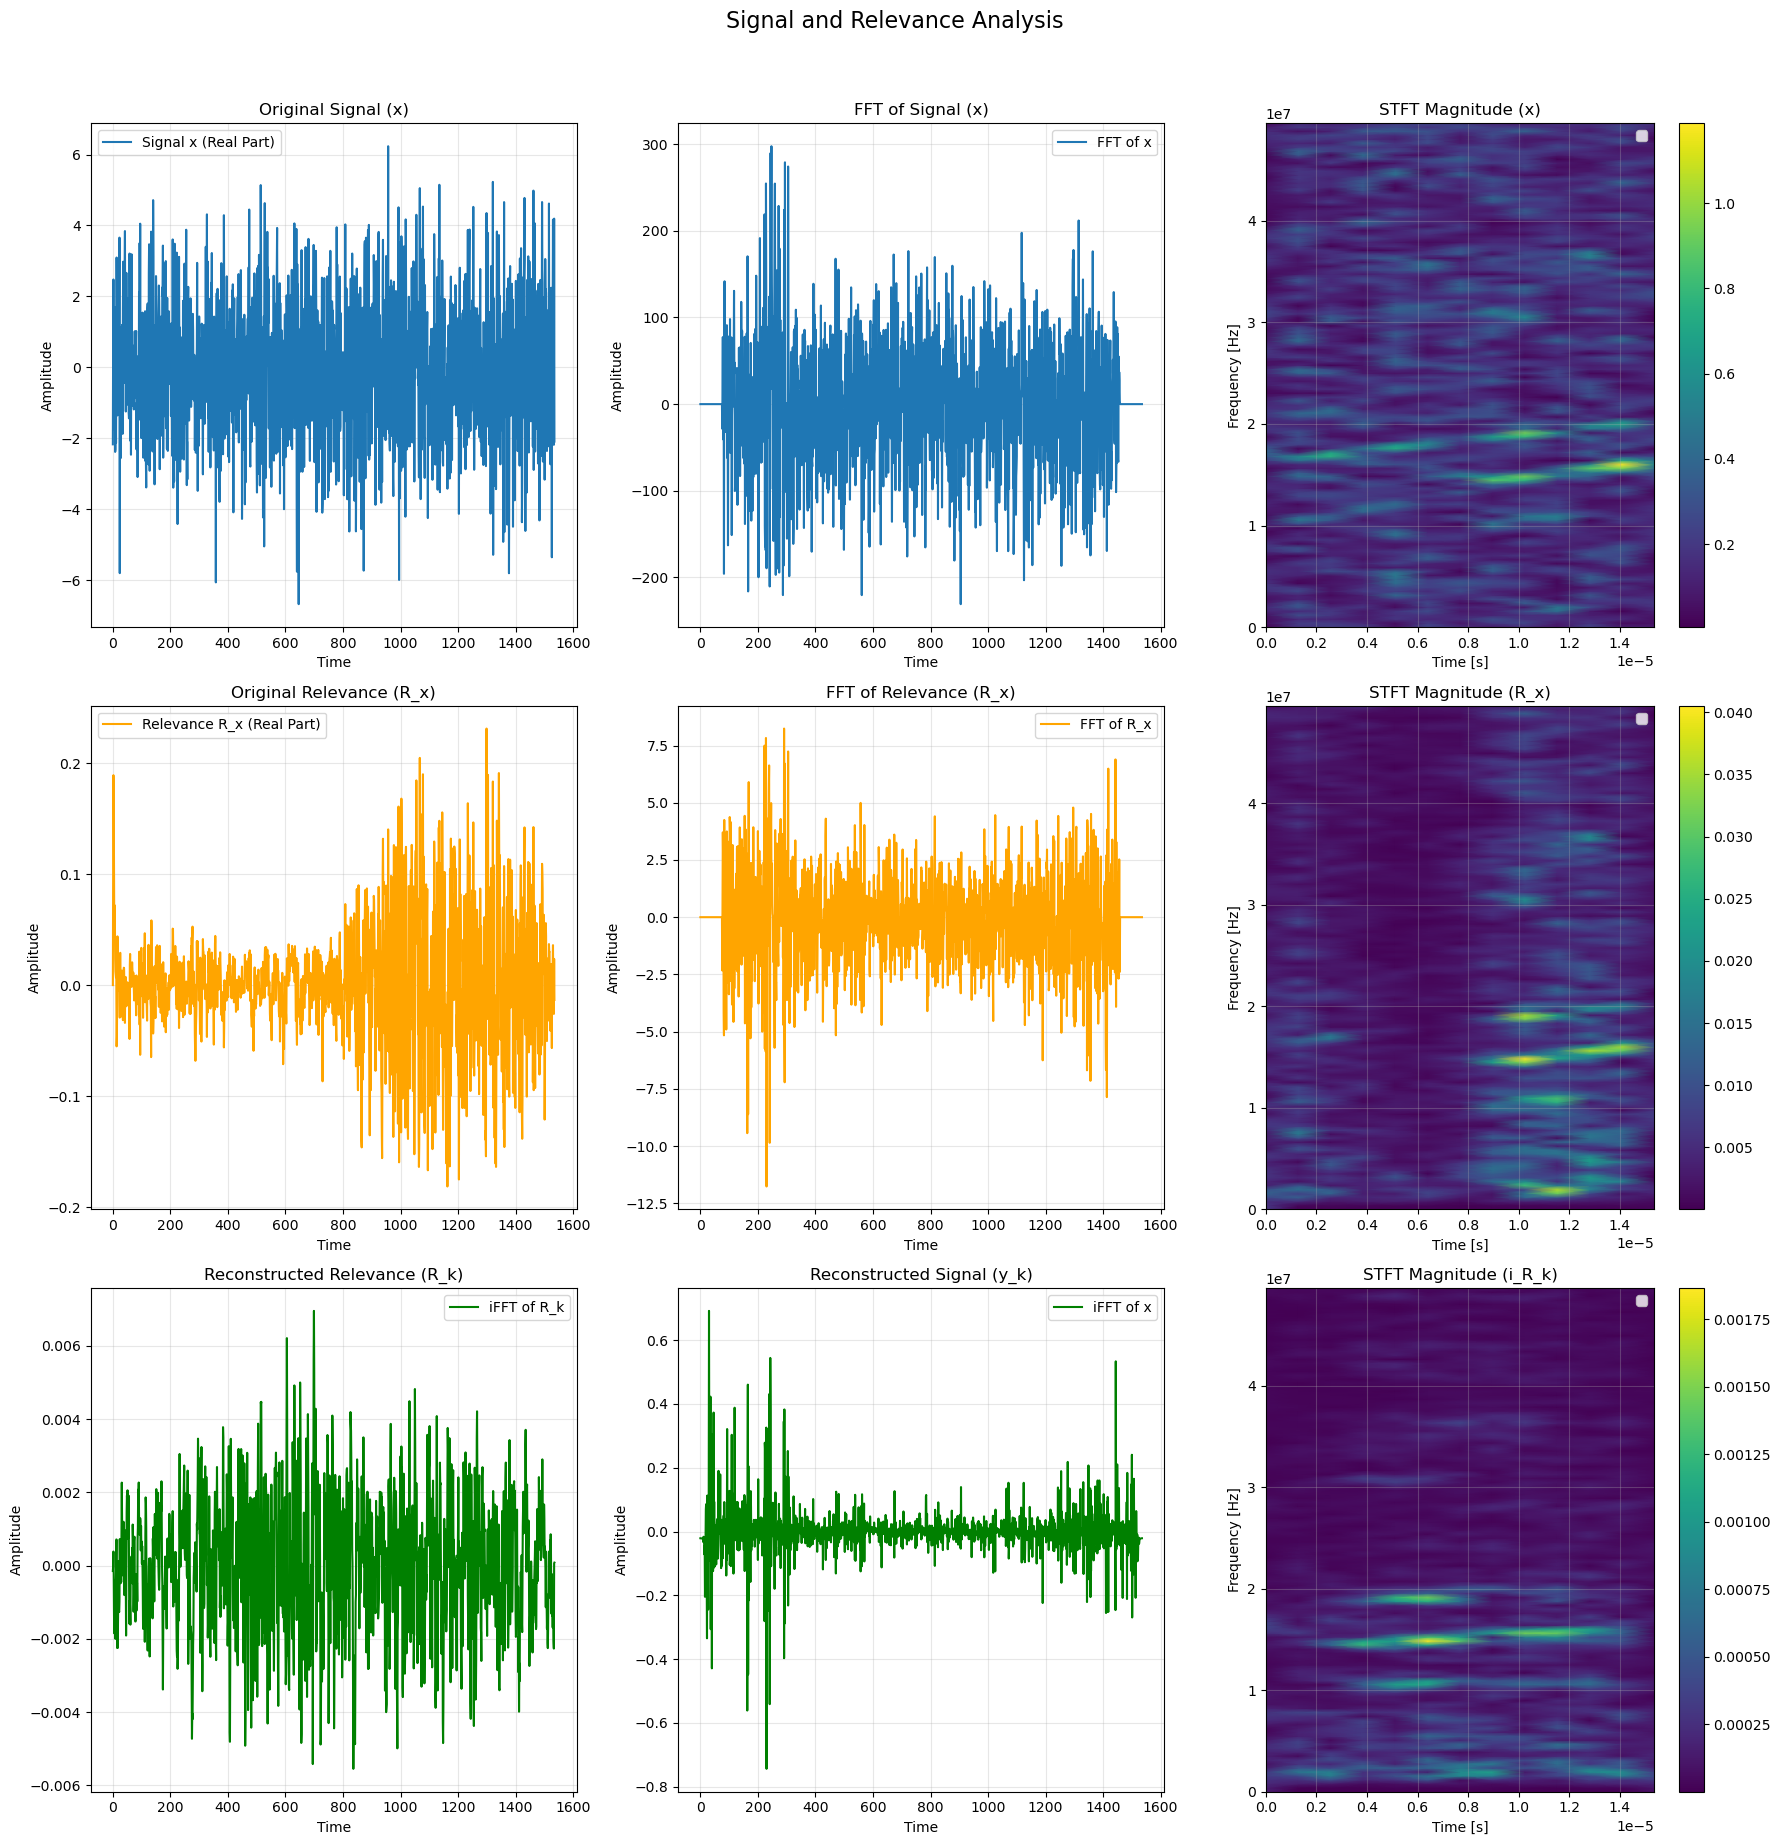

In [ ]:

import os
import torch
import numpy as np
import models._config as c

from models._config import *
from ex_models.LRP import LRP
from models.LSTM import BiLSTM
from scipy.signal import butter, filtfilt
from warnings import filterwarnings
filterwarnings("ignore")


def load_models(path='./ckpts/result_loss.pt', device='cuda:0'):
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    
    lrp = LRP(model, device=device, epsilon=1e-6)
    return model ,lrp

from scipy.signal import butter, filtfilt

def highpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)


def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)

test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_class_dB'
data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snr_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')


data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle


def filter_high_harmonics(fft_data, low_cut=0.05, high_cut=0.95):
    n = len(fft_data)
    low_idx = int(n * low_cut)   # 하위 컷오프 인덱스
    high_idx = int(n * high_cut)  # 상위 컷오프 인덱스
    
    filtered_fft = np.zeros_like(fft_data)  # 초기화
    filtered_fft[low_idx:high_idx] = fft_data[low_idx:high_idx]  # 필요한 대역만 유지
    return filtered_fft

def highpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

def relevance_k(rfft):
    magnitude =  rfft
    relevance = magnitude / np.sum(magnitude)  # 정규화된 중요도 계산
    return relevance * rfft  # 원래 주파수 성분의 크기와 위상 보존

snr_values = sorted(set(snr_batch.flatten()))  
score_snr_dict = {snr: {waveform: {'score': [], 'Nscore': [], 'Wscore': [], 'Rscore': []} for waveform in c.waveforms} for snr in snr_values}

fig, axes = plt.subplots(3, 3, figsize=(18, 20))  # 플롯 크기 설정
fig.suptitle('Signal and Relevance Analysis', fontsize=16, y=0.92)

for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    data = data_dict[batch_key]
    label = labels_dict[batch_key]
    relevance = relevance_dict[batch_key]

    data, label, length, relevance, snr, idx = shuffle(data, label, lengths_batch[batch], relevance, snr_batch[batch], idx_batch[batch])
    for j, sample in enumerate(zip(data, label, length, relevance, snr, idx)):  
        data, label, length, relevance, snr, idx = sample
        
        wav_path = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
        wav = np.load(wav_path)
        
        # data, relevance
        x = data[:length].cpu().numpy().T
        R_x = relevance[:length].cpu().numpy().T
        
        x = comp(x[0], x[1])
        R_x = comp(R_x[0], R_x[1])

        # FFT
        xf, xa, xfft = fft_transform(x.real, x.imag)
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        
        # 주파수 도메인에서 새롭게 Relevance 계산
        R_k = relevance_k(rfft)
        R_x = highpass_filter(R_x, 1e6, fs)
        
        # i-FFT: 새롭게 계산된 Relevance를 시간 도메인으로 변환
        i_x = ifft_transform(xfft)
        i_R_k = ifft_transform(R_k)
        i_R_k = highpass_filter(i_R_k, 1e6, fs)
        irf, ira, i_R_fft = fft_transform(i_R_k.real, i_R_k.imag)
        
        # STFT
        f_x, t_x, Zxx_x = stft_transform(x.real, x.imag)
        f_R_x, t_R_x, Zxx_R_x = stft_transform(R_x.real, R_x.imag)
        
        # IFFT-STFT
        f_ix, t_ix, Zxx_ix = stft_transform(i_x.real, i_x.imag)
        f_iR_k, t_iR_k, Zxx_iR_k = stft_transform(i_R_k.real, i_R_k.imag)
        
        xfft = filter_high_harmonics(xfft)
        rfft = filter_high_harmonics(rfft)

        # Plot 설정 및 결과 시각화
        # Row 1: 원본 데이터 및 FFT 변환 결과
        axes[0, 0].plot(x, label='Signal x (Real Part)')
        axes[0, 0].set_title('Original Signal (x)')
        axes[0, 1].plot(xfft, label='FFT of x')
        axes[0, 1].set_title('FFT of Signal (x)')
        pcm = axes[0, 2].pcolormesh(t_x, f_x[:len(f_x)//2], Zxx_x[:len(f_x)//2],
                                    shading='gouraud', cmap='jet')
        axes[0, 2].set_title('STFT Magnitude (x)')
        fig.colorbar(pcm, ax=axes[0, 2], orientation='vertical')

        # Row 2: 원본 Relevance 및 FFT 변환 결과
        axes[1, 0].plot(R_x, label='Relevance R_x (Real Part)', color='orange')
        axes[1, 0].set_title('Original Relevance (R_x)')
        axes[1, 1].plot(rfft, label='FFT of R_x', color='orange')
        axes[1, 1].set_title('FFT of Relevance (R_x)')
        pcm = axes[1, 2].pcolormesh(t_R_x, f_R_x[:len(f_R_x)//2],  Zxx_R_x[:len(f_R_x)//2],
                                    shading='gouraud', cmap='jet')
        axes[1, 2].set_title('STFT Magnitude (R_x)')
        fig.colorbar(pcm, ax=axes[1, 2], orientation='vertical')

        # Row 3: iFFT를 통해 복원된 신호 및 STFT
        
        axes[2, 0].plot(i_R_k, label='iFFT of R_k', color='green')
        axes[2, 0].set_title('Reconstructed Relevance (R_k)')
        axes[2, 1].plot(i_R_fft, label='iFFT of x', color='green')
        axes[2, 1].set_title('Reconstructed Signal (y_k)')
        pcm = axes[2, 2].pcolormesh(t_iR_k, f_iR_k[:len(f_iR_k)//2],  Zxx_iR_k[:len(f_iR_k)//2],
                                    shading='gouraud', cmap='jet')
        axes[2, 2].set_title('STFT Magnitude (i_R_k)')
        fig.colorbar(pcm, ax=axes[2, 2], orientation='vertical')

        # 공통 설정: 각 축에 라벨 추가
        for row_axes in axes:
            for ax in row_axes:
                ax.set_xlabel('Time' if 'STFT' not in ax.get_title() else 'Time [s]')
                ax.set_ylabel('Amplitude' if 'STFT' not in ax.get_title() else 'Frequency [Hz]')
                ax.legend()
                ax.grid(alpha=0.3)

        break
    break
        
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
        


NameError: name 'snr_batch' is not defined

# Train code 

In [ ]:
import os
import models._config as c
from dataset.LPIdataset import LPIDataset

data_dir = '/data/kiwan/LPI_KIWAN/STFT'
dataset = LPIDataset(data_dir, c.waveforms, data_type='pwnNoisy', model_type='UNet')

sample = dataset[0]
print(sample[0].shape, sample[1], sample[2])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import models._config as c

from tqdm import tqdm
from torch.utils.data import DataLoader
from models.LSTM import BiLSTM
from models.UNET import UNet, U2Net
from dataset.LPIdataset import LPIDataset

import torch.nn.utils.rnn as rnn_utils



def collate(batch):
    if len(batch[0])==4:  
        data, labels, lengths, snr = zip(*batch)
        data = [torch.tensor(seq, dtype=torch.float32) for seq in data]
        data_pad = rnn_utils.pad_sequence(data, batch_first=True)

        label_to_index = {label: idx for idx, label in enumerate(c.waveforms)}
        labels = torch.tensor([label_to_index[label] for label in labels], dtype=torch.long)
        lengths = torch.tensor(lengths, dtype=torch.int64)
        return data_pad, labels, lengths, snr

    else:  # UNet 또는 U2Net 모델
        data, labels, snr = zip(*batch)
        data = torch.stack(data, dim=0)
        label_to_index = {label: idx for idx, label in enumerate(c.waveforms)}
        labels = torch.tensor([label_to_index[label] for label in labels], dtype=torch.long)
        return data, labels, None, snr
    
def Train(model_type, data_dir, waveforms, datatype='pwnNoisy', batch_size=256, epochs=500, learning_rate=0.001, weight_decay=1e-5, device_ids=[0, 1]):
    CEloss = nn.CrossEntropyLoss()
    
    if model_type == 'BiLSTM':
        model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms))
    elif model_type == 'UNet':
        model = UNet(in_channels=3, out_channels=len(waveforms))
    elif model_type == 'U2Net':
        model = U2Net(in_channels=3, out_channels=len(waveforms))
    else:
        raise ValueError("Invalid model_type. Choose from 'BiLSTM', 'UNet', 'U2Net'.")
    
    model = nn.DataParallel(model, device_ids=device_ids).cuda()
    model.train()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    dataset = LPIDataset(data_dir, waveforms, data_type=datatype, model_type=model_type)
    dataload = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate)
    
    best_loss = float('inf')
    best_state = None
    losses = []

    for epoch in range(epochs):
        total_loss = 0.0
        progress = tqdm(enumerate(dataload), total=len(dataload), desc=f"Epoch {epoch + 1}/{epochs}", leave=False)

        for batch_idx, (data, labels, lengths, snrs) in progress:
            if model_type == 'BiLSTM':
                # BiLSTM은 시계열 입력
                data, labels = data.cuda(), labels.cuda()
                outputs = model(data, lengths)
            else:
                # UNet, U2Net은 TFI 이미지 입력
                data, labels = data.cuda(), labels.cuda()
                outputs = model(data)



            loss = CEloss(outputs, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            total_loss += loss.item()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            progress.set_postfix({'Batch': f'{batch_idx+1}/{len(dataload)}', 'Loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / len(dataload)
        losses.append(avg_loss)
        
        print(f'Epoch : {epoch+1}/{epochs}, Loss : {avg_loss:.4f}')
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = model.state_dict()
            torch.save(best_state, f'./ckpts/{datatype}/{model_type}_best_{best_loss:.4f}.pth')
            if best_loss < 0.002:
                break

        torch.cuda.empty_cache()
    
    torch.save(model.state_dict(), f'./ckpts/{datatype}/{model_type}_last_{best_loss:.4f}.pth')
    

model_type = 'UNet'
data_dir = '/data/kiwan/LPI_KIWAN/STFT'
datatypes = ['Signal', 'Noise', 'Noisy', 'pwnNoisy']
    
Train(
        model_type=model_type,
        batch_size=64,
        epochs=500,
        learning_rate=1e-3,
        weight_decay=1e-5,
        data_dir=data_dir,
        datatype=datatypes[-1],
        waveforms=c.waveforms
    )


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.rnn as rnn_utils
from tqdm import tqdm
from torch.utils.data import DataLoader

import models._config as c
from models.LSTM import BiLSTM
from dataset.LPIdataset import LPIDataset

    
datatypes = c.datatypes
       
def collate(batch):
    data, labels, lengths, _, _, _ = zip(*batch)
    data = [torch.tensor(seq, dtype=torch.float32) for seq in data]
    data_pad = rnn_utils.pad_sequence(data, batch_first=True)
    labels = torch.tensor([c.label_mapping[label] for label in labels], dtype=torch.long)
    lengths = torch.tensor(lengths, dtype=torch.int64)
    
    return data_pad, labels, lengths

torch.cuda.set_device(1)
CEloss = nn.CrossEntropyLoss()
model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(c.waveforms)).cuda()
# model = nn.DataParallel(model, device_ids=[0, 1]).cuda()
model.train()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

dataset = LPIDataset(c.data_dir, c.waveforms, data_type=datatypes[-1])              
dataload = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate)

best_loss = float('inf')
best_state = None

losses = []
epochs = 500
for epoch in range(epochs):
    total_loss = 0.0
    progress = tqdm(enumerate(dataload), total=len(dataload), desc=f"Epoch {epoch + 1}/{epochs}", leave=False)
        
    for batch_idx, (data, labels, lengths) in progress:
        optimizer.zero_grad()
        data, labels = data.cuda(), labels.cuda()
        outputs = model(data, lengths)
        loss = CEloss(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        progress.set_postfix({'Batch': f'{batch_idx+1}/{len(dataload)}', 'Loss': f'{loss.item():.4f}'})

        loss.detach()
    
    avg_loss = total_loss / len(dataload)
    losses.append(avg_loss)
    
    print(f'Epoch : {epoch+1}/{epochs}, Loss : {avg_loss:.4f}')
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = model.state_dict()
        torch.save(best_state, f'./models/{datatypes[-1]}_best_{best_loss}.pth')
        if best_loss < 0.01:
            break
    torch.cuda.empty_cache()
torch.save(model.state_dict(), f'./models/{datatypes[-1]}_last_{best_loss}.pth')


# dataset 전부 삭제하기 (데이터셋 테스트할 때 사용)

In [ ]:
import os
import shutil

data_dir = '/data/kiwan/LPI_KIWAN/'
files = os.listdir(data_dir)

for file in files:
    file_path = os.path.join(data_dir, file)
    if os.path.isfile(file_path):
        os.remove(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print(f"All files in {data_dir} have been deleted.")


# 데이터셋 각 클래스 별 length 분포 확인

In [ ]:
import os
import numpy as np

class LPIDataset:
    def __init__(self, data_dir, waveforms, data_type='Signal'):
        self.data_dir = data_dir
        self.waveform = waveforms
        self.data_type = data_type
        self.file_list = self._collect()

    def _collect(self):
        files = []
        for waveform in self.waveform:
            waveform_folder = os.path.join(self.data_dir, waveform)
            files.extend([f for f in os.listdir(waveform_folder) if self.data_type in f])
        
        return files

    def _parse(self, file):
        parts = file.replace('.npy', '').split('_')
        label, snr, type, fps_idx = parts[0], int(parts[1].replace('snr', '')), parts[2], int(parts[3])
        
        return type, label, snr, fps_idx

    def _convIQ(self, complex_data):
        return complex_data.real, complex_data.imag
    
    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file = self.file_list[idx]
        type, label, snr, fps_idx= self._parse(file)
        file_path = os.path.join(self.data_dir, label, file)
        
        IQ_data = [self._convIQ(c) for c in np.load(file_path)]
        
        return IQ_data, label, len(IQ_data), snr, type, fps_idx 
    

data_dir = '/data/kiwan/LPI_KIWAN/'
datatypes = ['Signal', 'Noise', 'Noisy', 'pwnNoisy']
waveforms = ['LFM', 'Costas', 'Barker', 'Frank', 'P1', 'P2', 'P3', 'P4', 'T1', 'T2', 'T3', 'T4']
dataset = LPIDataset(data_dir, waveforms, data_type=datatypes[-1])


import matplotlib.pyplot as plt

class_lengths = {waveform: [] for waveform in waveforms}

for idx in range(len(dataset)):
    _, label, length, _, _, _ = dataset[idx]
    class_lengths[label].append(length)

fig, ax = plt.subplots(figsize=(12, 8))

for label, lengths in class_lengths.items():
    # if label in ['P3', 'P4']:
    #     count = sum(1 for length in lengths if length >= 2000)
    #     print(f'Number of {label} signals with length >= 2000: {count}')
    ax.hist(lengths, label=label, bins=50, alpha=0.6)

ax.set_title('Length Distribution per Class')
ax.set_xlabel('Length')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

In [ ]:
from models._config import C
from dataset.RadarDataset import RadarSignalDataset  


c = C()
if __name__ == "__main__":
    datajson = c.dataload(csv=True, mode='train')
    dataset = RadarSignalDataset(datajson, c.signalTypes[0:c.typeSize], snr_max=2)

In [ ]:
import matplotlib.pyplot as plt

class_lengths = {signal_type: [] for signal_type in set(dataset.labels)}

for idx in range(len(dataset)):
    _, label, _, length = dataset[idx]
    class_lengths[label].append(length)

fig, ax = plt.subplots(figsize=(12, 8))

for label, lengths in class_lengths.items():
    if label in ['T1', 'T2', 'T3', 'T4']:
        ax.hist(lengths, label=label, bins=50, alpha=0.6)

ax.set_title('Length Distribution per Class')
ax.set_xlabel('Length')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

In [ ]:
import numpy as np
import torch   
import torch.nn as nn
from torch.utils.data import DataLoader
from models.LSTM import BiLSTM
import matplotlib.pyplot as plt
from scipy.signal import stft

model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=12)
model.to(c.device)
model.eval()


fs = 100e6
batch_size = 4

# Filter dataset to include only specific labels
target_label = 'Costas'
target_indices = [idx for idx, (_, label, _, _) in enumerate(dataset) if label in target_label]
target_dataset = torch.utils.data.Subset(dataset, target_indices)
loader = DataLoader(target_dataset, batch_size=batch_size, shuffle=False, collate_fn=model.collate)

def logscale(x, eb=1e-6):
    return np.log(np.abs(x)+eb)



for batch_data, batch_label, batch_snr, batch_length in loader:
    batch_data = batch_data.to(c.device)
    fig, axes = plt.subplots(batch_size, 10, figsize=(30, 15))
    for i, sample in enumerate(zip(batch_data, batch_label, batch_snr, batch_length)):
        data, label, _, length = sample
        label = c.signalTypes[label]
        
        
        x_I = data[:length, 0].cpu().numpy()
        x_Q = data[:length, 1].cpu().numpy()
        
        f, t, Zxx = stft(x_I + x_Q, fs=fs, nperseg=256)
        f_I, t_I, Zxx_I = stft(x_I, fs=fs, nperseg=256)
        f_Q, t_Q, Zxx_Q = stft(x_Q, fs=fs, nperseg=256)
        
        logx_I = logscale(x_I, eb=1e-3)
        logx_Q = logscale(x_Q, eb=1e-3)
        
        log_f, log_t, log_Zxx = stft(logx_I + logx_Q, fs=fs, nperseg=256)
        log_f_I, log_t_I, log_Zxx_I = stft(logx_I, fs=fs, nperseg=256)
        log_f_Q, log_t_Q, log_Zxx_Q = stft(logx_Q, fs=fs, nperseg=256)
        
        axes[i, 0].plot(x_I, label='I')
        axes[i, 1].plot(x_Q, label='Q')
        axes[i, 2].plot(logx_I, label='I')
        axes[i, 3].plot(logx_Q, label='Q')
        axes[i, 4].pcolormesh(t_I, f_I, np.abs(Zxx_I), shading='gouraud')
        axes[i, 5].pcolormesh(t_Q, f_Q, np.abs(Zxx_Q), shading='gouraud')
        axes[i, 6].pcolormesh(log_t_I, log_f_I, np.abs(log_Zxx_I), shading='gouraud')
        axes[i, 7].pcolormesh(log_t_Q, log_f_Q, np.abs(log_Zxx_Q), shading='gouraud')
        axes[i, 8].pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
        axes[i, 9].pcolormesh(log_t, log_f, np.abs(log_Zxx), shading='gouraud')
        
        
        axes[i, 0].set_title(f'I-{label}')
        axes[i, 1].set_title(f'Q-{label}')
        axes[i, 2].set_title(f'logscaled-I-{label}')
        axes[i, 3].set_title(f'logscaled-Q-{label}')
        axes[i, 4].set_title(f'STFT-{label}')
        axes[i, 5].set_title(f'logscaled-STFT-{label}')
        
    break
    # with torch.no_grad():
    #     outputs = model(batch_data, batch_length)
        
    #     break
    
    plt.tight_layout()
    

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Define the directory containing the dataset
dataset_directory = '/data/kiwan/LPI_Radar_1000_'
sclass = ['Barker', 'Costas', 'Frank', 'LFM', 'P1', 'P2', 'P3', 'P4', 'T1', 'T2', 'T3', 'T4']
j = 0
for cls in sclass:
    print(cls, end=' ')
    pth = os.path.join(dataset_directory, cls)
    files = os.listdir(pth)
    i = 0
    for file in files:
        if not file.endswith('-noisy.npy'):
            continue
        # print('Processing', cls, file)
        data = np.load(os.path.join(pth, file))
        print(data.shape, end=' ')
        data = data[:, 0]
        # plt.plot(data.shape)
        # plt.show()
        i = i + 1
        if i == 5:
            break
    print()
    j = j + 1
    if j == 12:
        break   
